# 03. EDA - TRỰC QUAN HÓA VÀ PHÂN TÍCH KHÁM PHÁ
**Mục tiêu:**
1. Phân tích đơn biến
2. Phân tích đa biến & tương quan 
3. Phân tích Dữ liệu phân loại
4. Phân tích xu hướng theo thời gian
---

## [*] Tải thư viện và file dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import math
import warnings
import re
from collections import Counter

warnings.filterwarnings('ignore')
print("Các thư viện đã sẵn sàng!")

plt.style.use('ggplot')
sns.set_theme(style='whitegrid')

# Đọc dữ liệu từ file CSV
df_eda = pd.read_csv('../data/processed/spotify_cleaned_scaled_v3.csv')
print(f"Đã tải dữ liệu: {df_eda.shape[0]} dòng, {df_eda.shape[1]} cột")


Các thư viện đã sẵn sàng!
Đã tải dữ liệu: 12476 dòng, 25 cột


## 1. Phân tích phân phối của từng thuộc tính âm học
Công cụ: Histogram, Boxplot

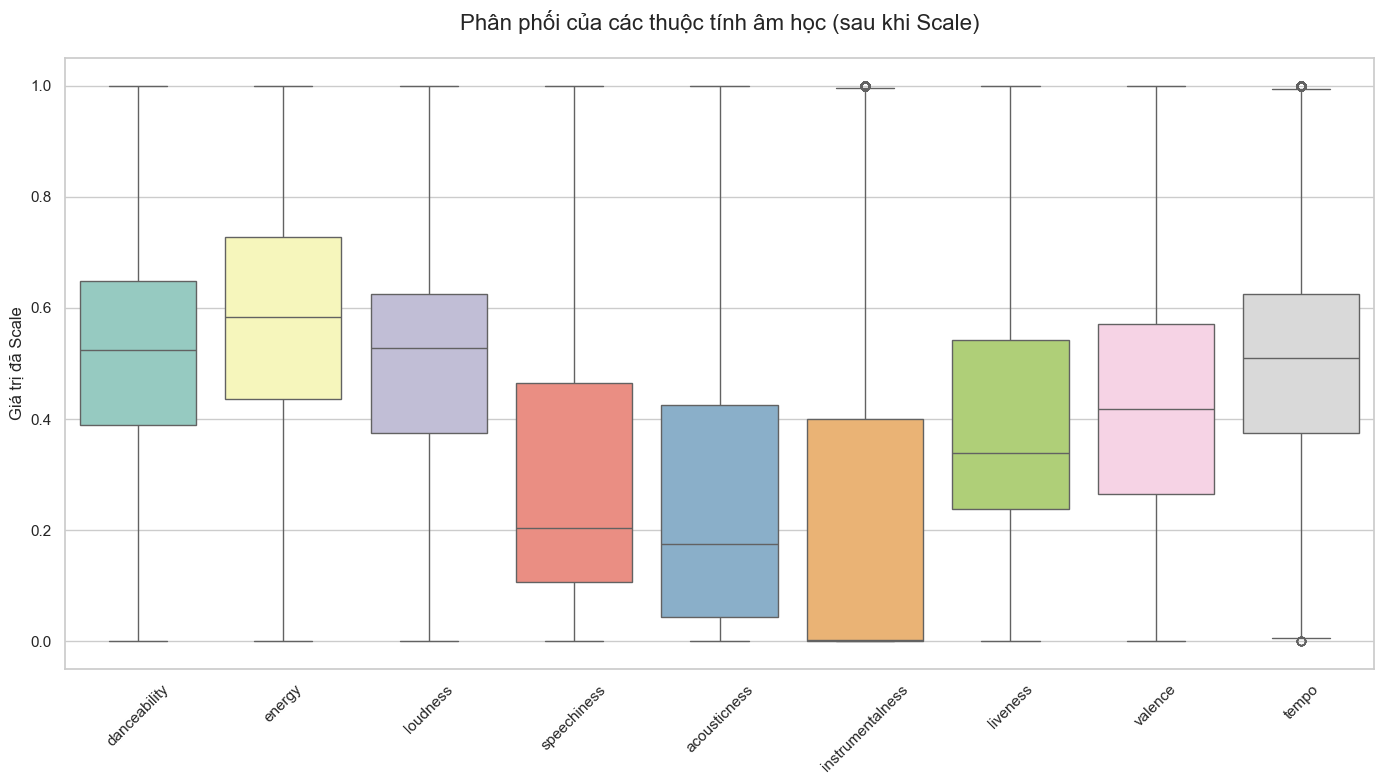

In [2]:
# Chọn các thuộc tính âm 
audio_features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

# Vẽ Boxplot cho các thuộc tính âm nhạc
plt.figure(figsize=(14, 8))
sns.boxplot(data=df_eda[audio_features], palette='Set3')
plt.title('Phân phối của các thuộc tính âm học (sau khi Scale)', fontsize = 16, pad = 20)
plt.xticks(rotation=45)
plt.ylabel('Giá trị đã Scale')
plt.tight_layout()
plt.show()

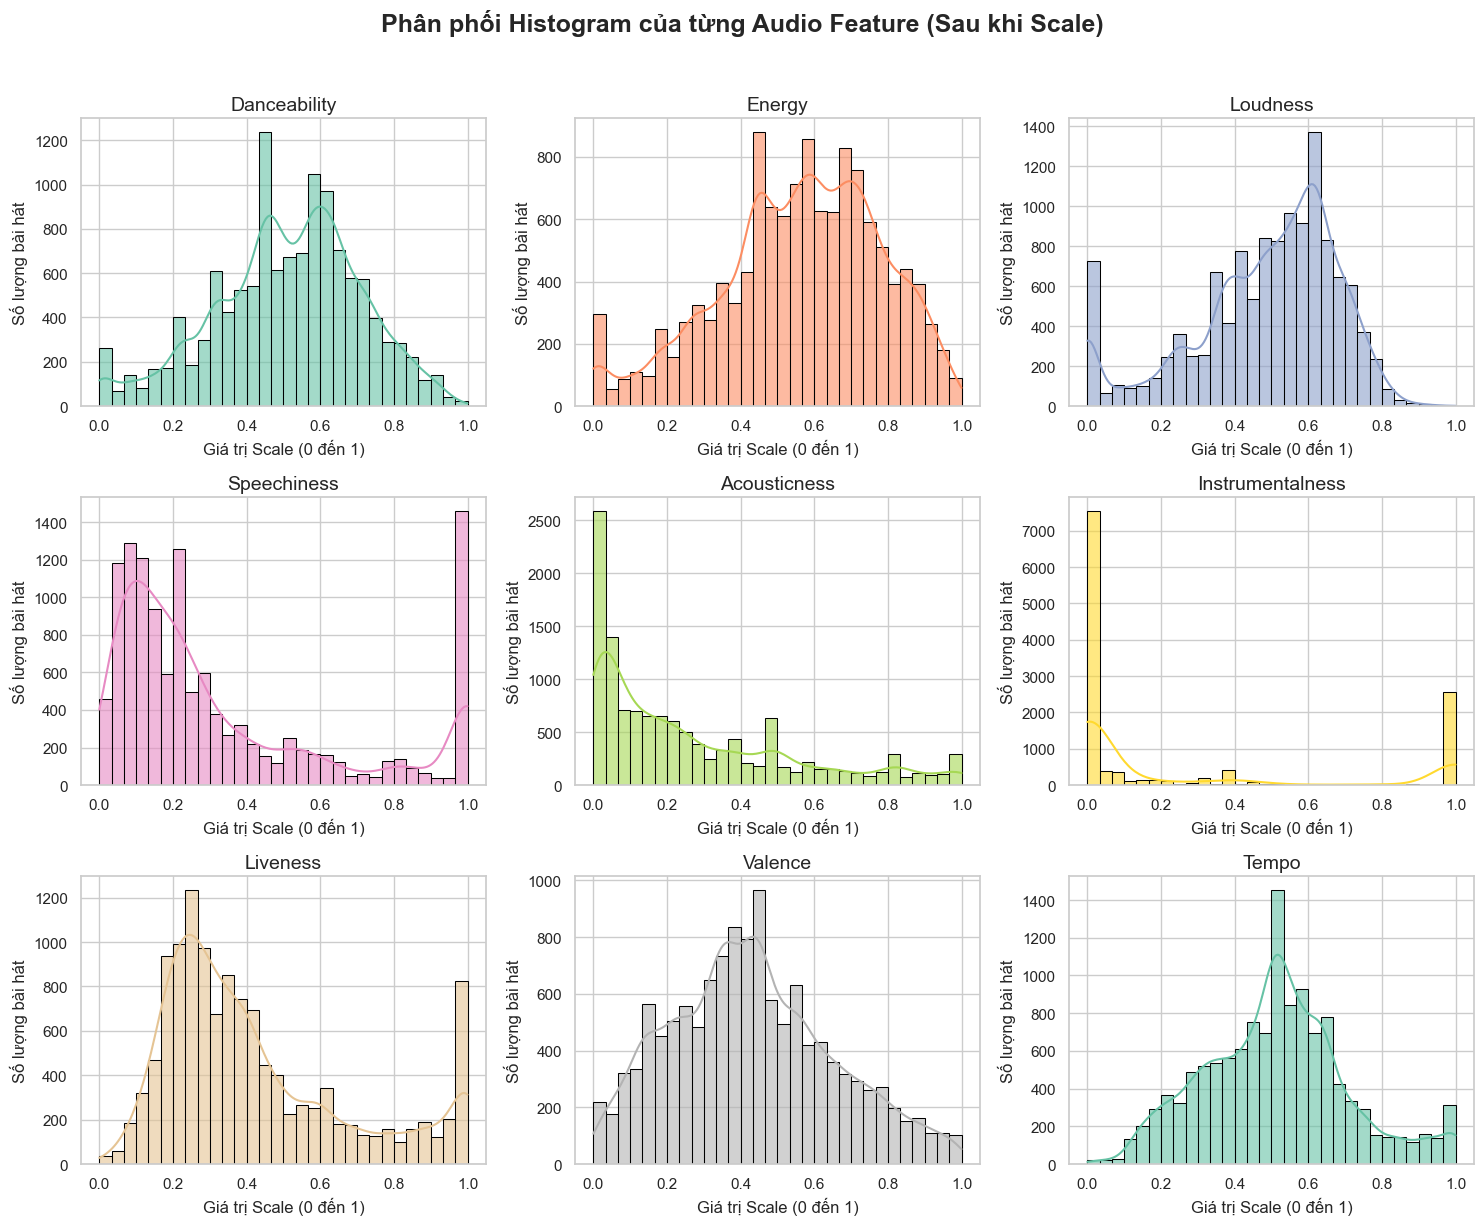

In [3]:
# Vẽ histogram cho từng thuộc tính âm nhạc
n_features = len(audio_features)
cols = 3
rows = math.ceil(n_features / cols)

# Khởi tạo khung biểu đồ (grid)
fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
fig.suptitle('Phân phối Histogram của từng Audio Feature (Sau khi Scale)', fontsize=18, fontweight='bold', y=1.02)

axes = axes.flatten()
for i, feature in enumerate(audio_features):
    sns.histplot(
        data=df_eda,
        x=feature, 
        ax=axes[i], 
        color=sns.color_palette("Set2")[i % 8],
        bins=30,      
        kde=True,     
        edgecolor='black',
        alpha=0.6     
    )
    axes[i].set_title(feature.capitalize(), fontsize=14)
    axes[i].set_xlabel('Giá trị Scale (0 đến 1)')
    axes[i].set_ylabel('Số lượng bài hát')
    
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 2. Ma trận tương quan 
Xem xét các thuộc tính có liên quan đến nhau. Tránh đưa các thuộc tính có tương quan quá mạnh vào cùng một mô hình thuật toán sau này để giảm nhiễu.

Công cụ: Correlation Heatmap

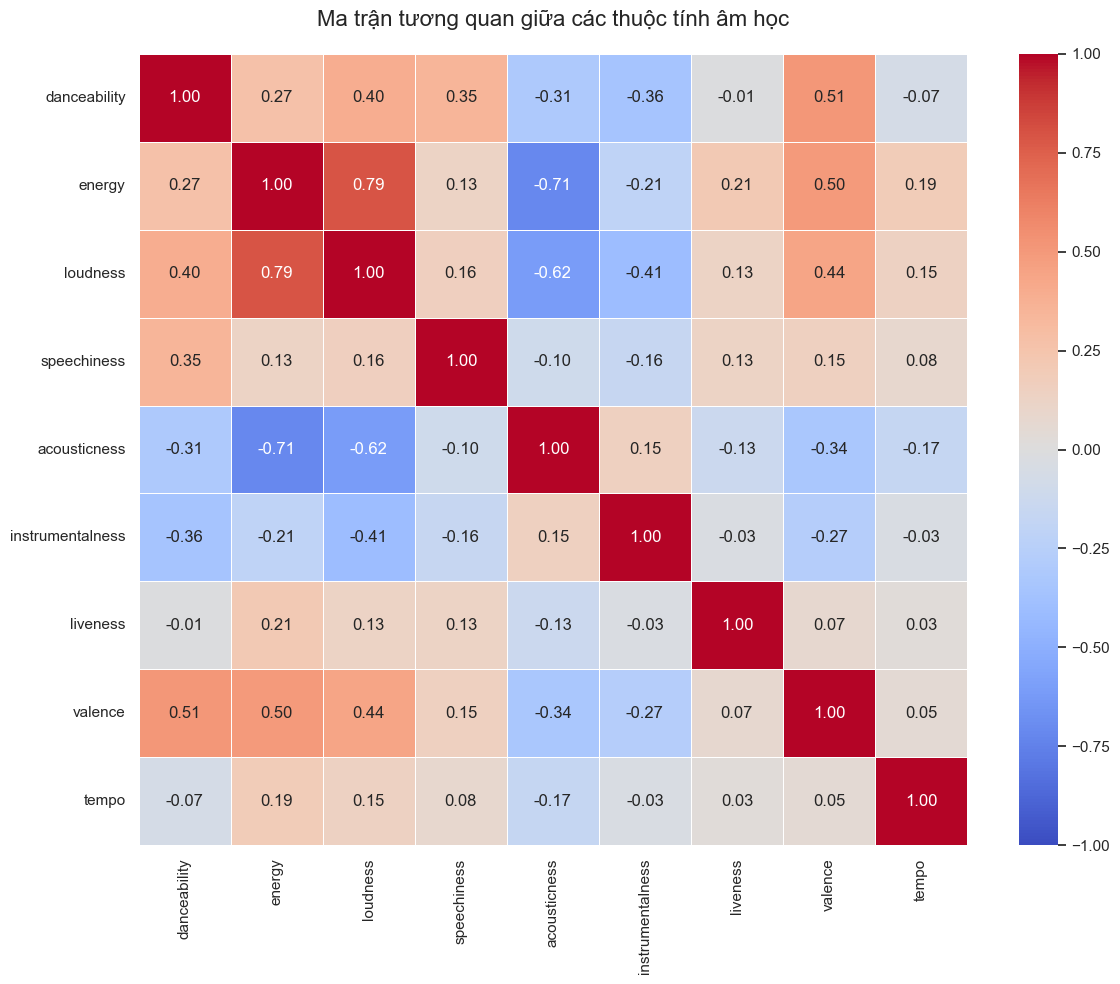

In [4]:
matrix_features = df_eda[audio_features].corr()

# Vẽ heatmap của ma trận tương quan
plt.figure(figsize=(12, 10))
sns.heatmap(matrix_features, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Ma trận tương quan giữa các thuộc tính âm học', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

## 3. Phân tích Dữ liệu phân loại 
Mục tiêu: Hiểu được cấu trúc dữ liệu, so sánh các nhóm và phát hiện các thuộc tính có khả năng phân loại cao, phục vụ tốt cho việc xây dựng mô hình về sau.




### Hiểu cấu trúc dữ liệu
Thống kê top các nghệ sĩ phổ biến nhất

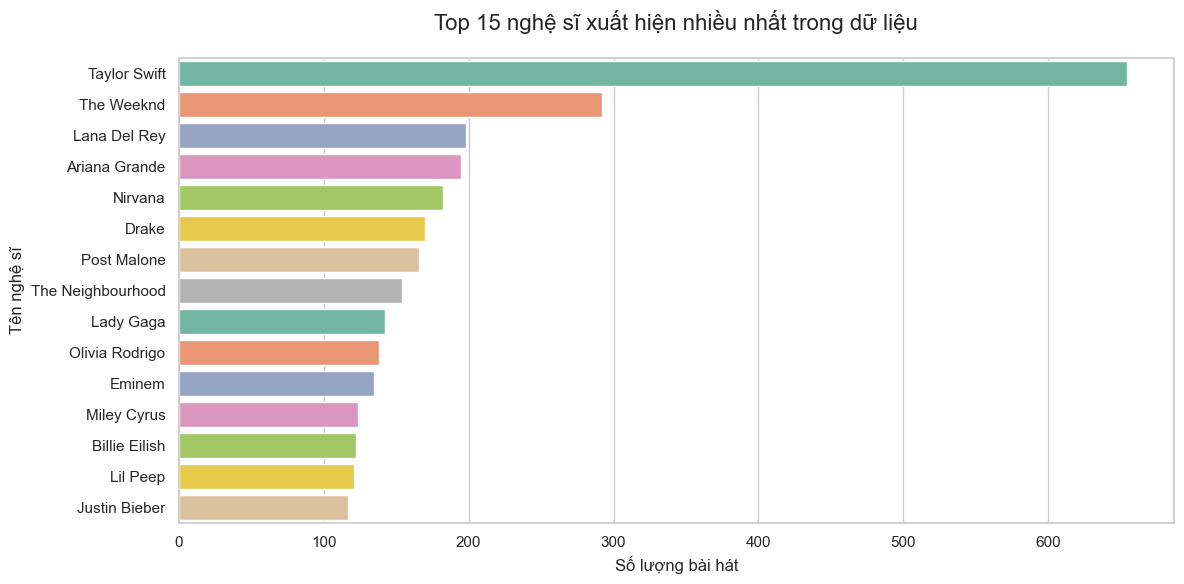

In [5]:
# Tính số lượng top 15 nghệ sĩ xuất hiện nhiều nhất trong dữ liệu
top_artists = df_eda['artist_name'].value_counts().head(15)

# Vẽ biểu đồ cột cho top 15 nghệ sĩ
plt.figure(figsize=(12, 6))
sns.barplot(x=top_artists.values, y=top_artists.index, palette='Set2')
plt.title('Top 15 nghệ sĩ xuất hiện nhiều nhất trong dữ liệu', fontsize=16, pad=20)
plt.xlabel('Số lượng bài hát')
plt.ylabel('Tên nghệ sĩ')
plt.tight_layout()
plt.show()

Thống kê top 10 thể loại âm nhạc phổ biến

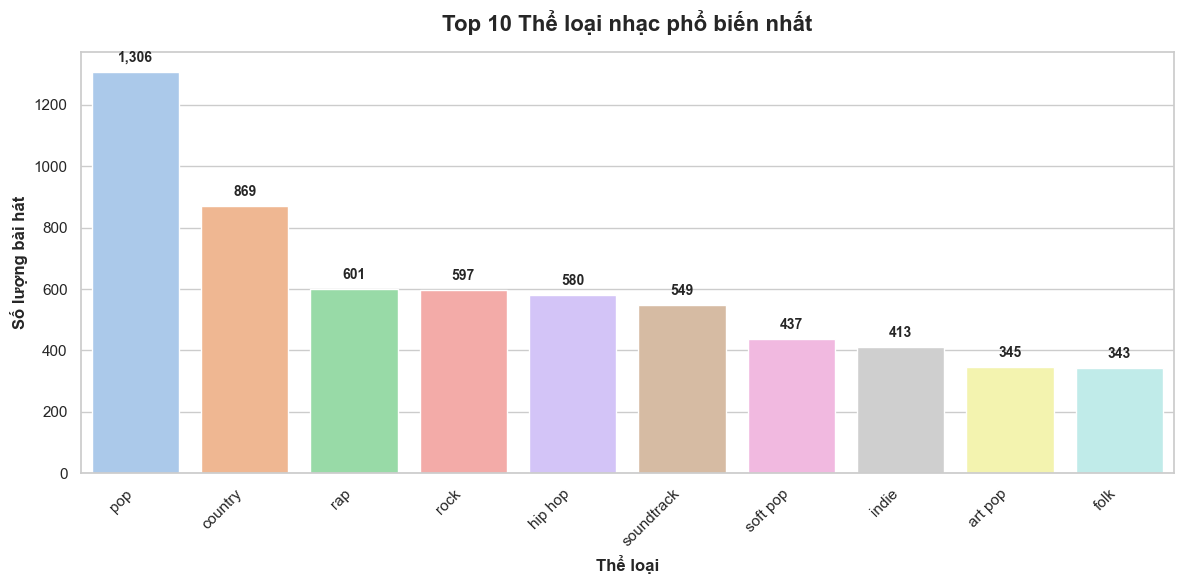

In [6]:
# Vẽ biểu đồ cột cho top 10 thể loại phổ biến nhất
plt.figure(figsize=(12, 6))
genre_col = 'artist_genres'
if genre_col in df_eda.columns:
    # Trích xuất và đếm nhanh thể loại từ cột dữ liệu gốc
    all_genres = []
    for val in df_eda[genre_col].dropna():
        val = re.sub(r'[\[\]\'"]', '', str(val))
        genres = [g.strip() for g in val.split(',') if g.strip() and g.strip().lower() != 'unknown']
        all_genres.extend(genres)
    
    # Lấy 10 thể loại phổ biến nhất
    top_10_genres = dict(Counter(all_genres).most_common(10))
    ax = sns.barplot(x=list(top_10_genres.keys()), y=list(top_10_genres.values()), palette='pastel')
    
    plt.title('Top 10 Thể loại nhạc phổ biến nhất', fontsize=16, fontweight='bold', pad=15)
    plt.ylabel('Số lượng bài hát', fontsize=12, fontweight='bold')
    plt.xlabel('Thể loại', fontsize=12, fontweight='bold')
    
    plt.xticks(rotation=45, ha='right', fontsize=11)
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'bottom', 
                    xytext = (0, 5), textcoords = 'offset points',
                    fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

### So sánh các nhóm
So sánh mức độ phổ biến (popularity) giữa nhạc Explicit và Non-Explicit

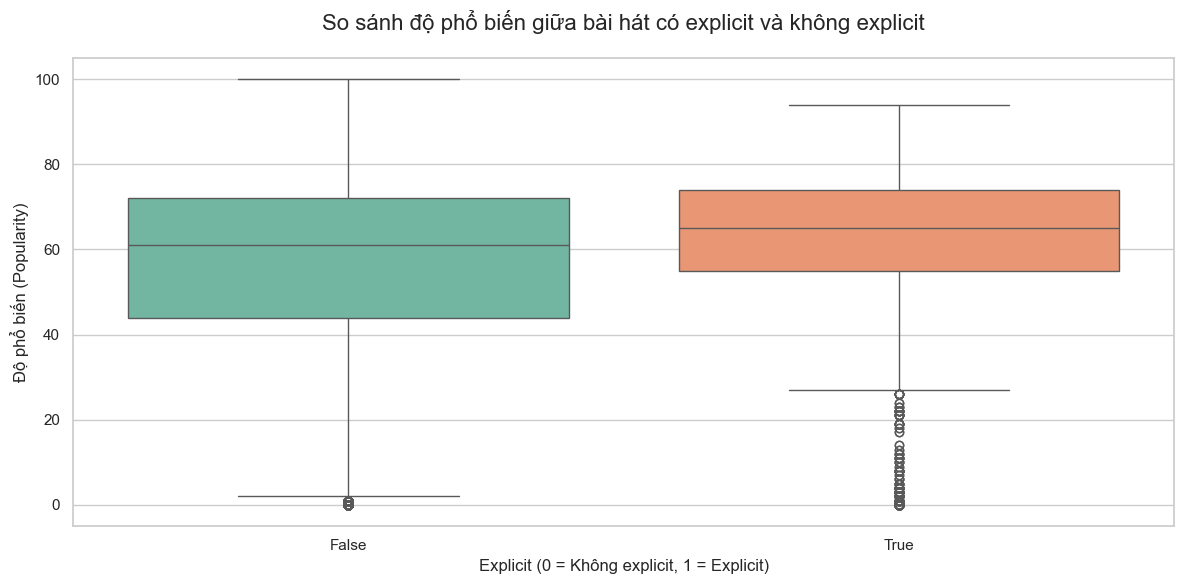

In [7]:
# Vẽ boxplot so sánh độ phổ biến giữa bài hát có explicit và không explicit
plt.figure(figsize=(12, 6))
sns.boxplot(x='explicit', y='track_popularity', data=df_eda, palette='Set2')
plt.title('So sánh độ phổ biến giữa bài hát có explicit và không explicit', fontsize=16, pad=20)
plt.xlabel('Explicit (0 = Không explicit, 1 = Explicit)')
plt.ylabel('Độ phổ biến (Popularity)')
plt.tight_layout()
plt.show()

So sánh tương quan giữa hai biến acousticness và energy (hai biến tương quan âm nhất)

Text(0, 0.5, 'Energy')

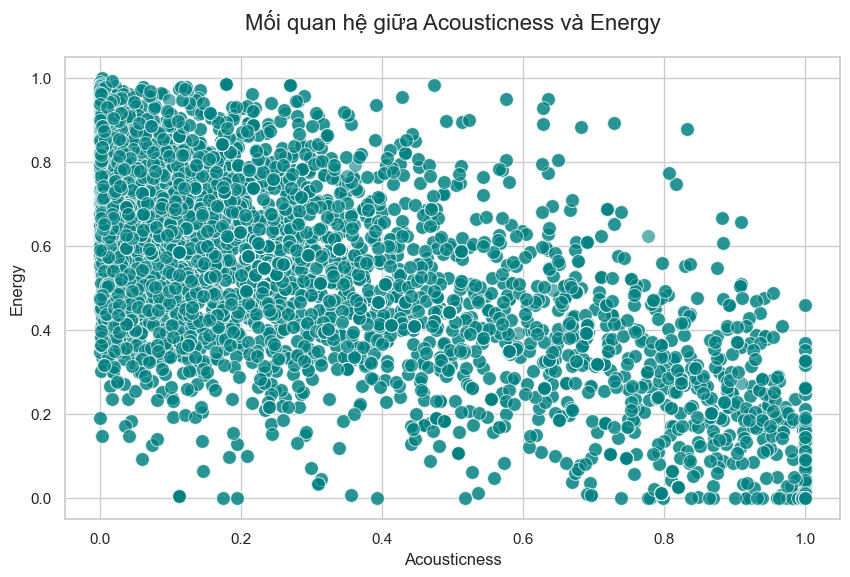

In [8]:
# Vẽ scatter plot giữa acousticness và energy
plt.figure(figsize=(10, 6))
sns.scatterplot(x='acousticness', y='energy', data=df_eda, alpha=0.6, edgecolor='w', s=100, color='teal')
plt.title('Mối quan hệ giữa Acousticness và Energy', fontsize=16, pad=20)
plt.xlabel('Acousticness')
plt.ylabel('Energy')

So sánh tương quan giữa hai biến loudness và energy (hai biến tương quan dương nhất)

Text(0, 0.5, 'Energy')

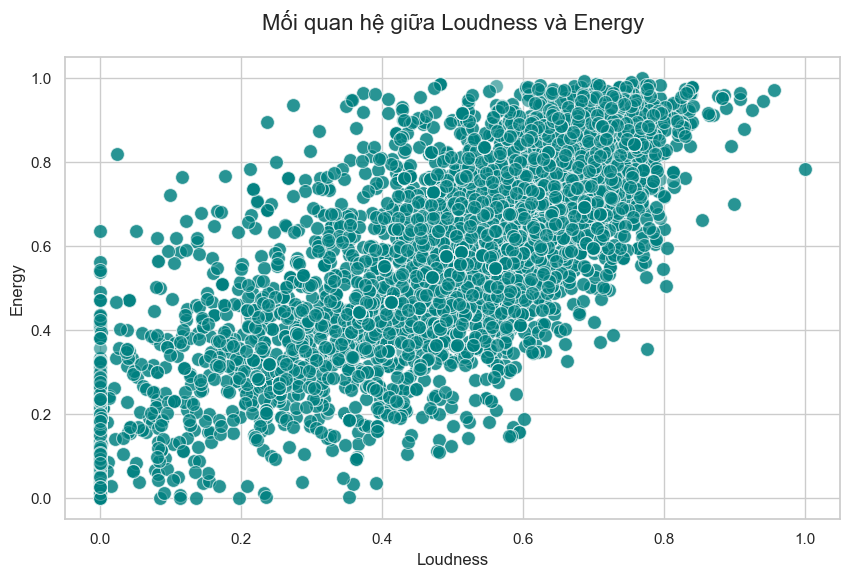

In [9]:
# Vẽ scatter plot giữa acousticness và energy
plt.figure(figsize=(10, 6))
sns.scatterplot(x='loudness', y='energy', data=df_eda, alpha=0.6, edgecolor='w', s=100, color='teal')
plt.title('Mối quan hệ giữa Loudness và Energy', fontsize=16, pad=20)
plt.xlabel('Loudness')
plt.ylabel('Energy')

## 4. Phân tích xu hướng âm nhạc theo thời gian
Mục tiêu: Theo dõi sự biến động của các biến Danceability, Energy và Valence theo từng năm đề xác định sự thay đổi thị hiếu âm nhạc từ năm 2009 đến 2025. Tạo story telling cho báo cáo

Công cụ: Line graph


Đang vẽ lưới biểu đồ xu hướng 9 đặc trưng âm học...


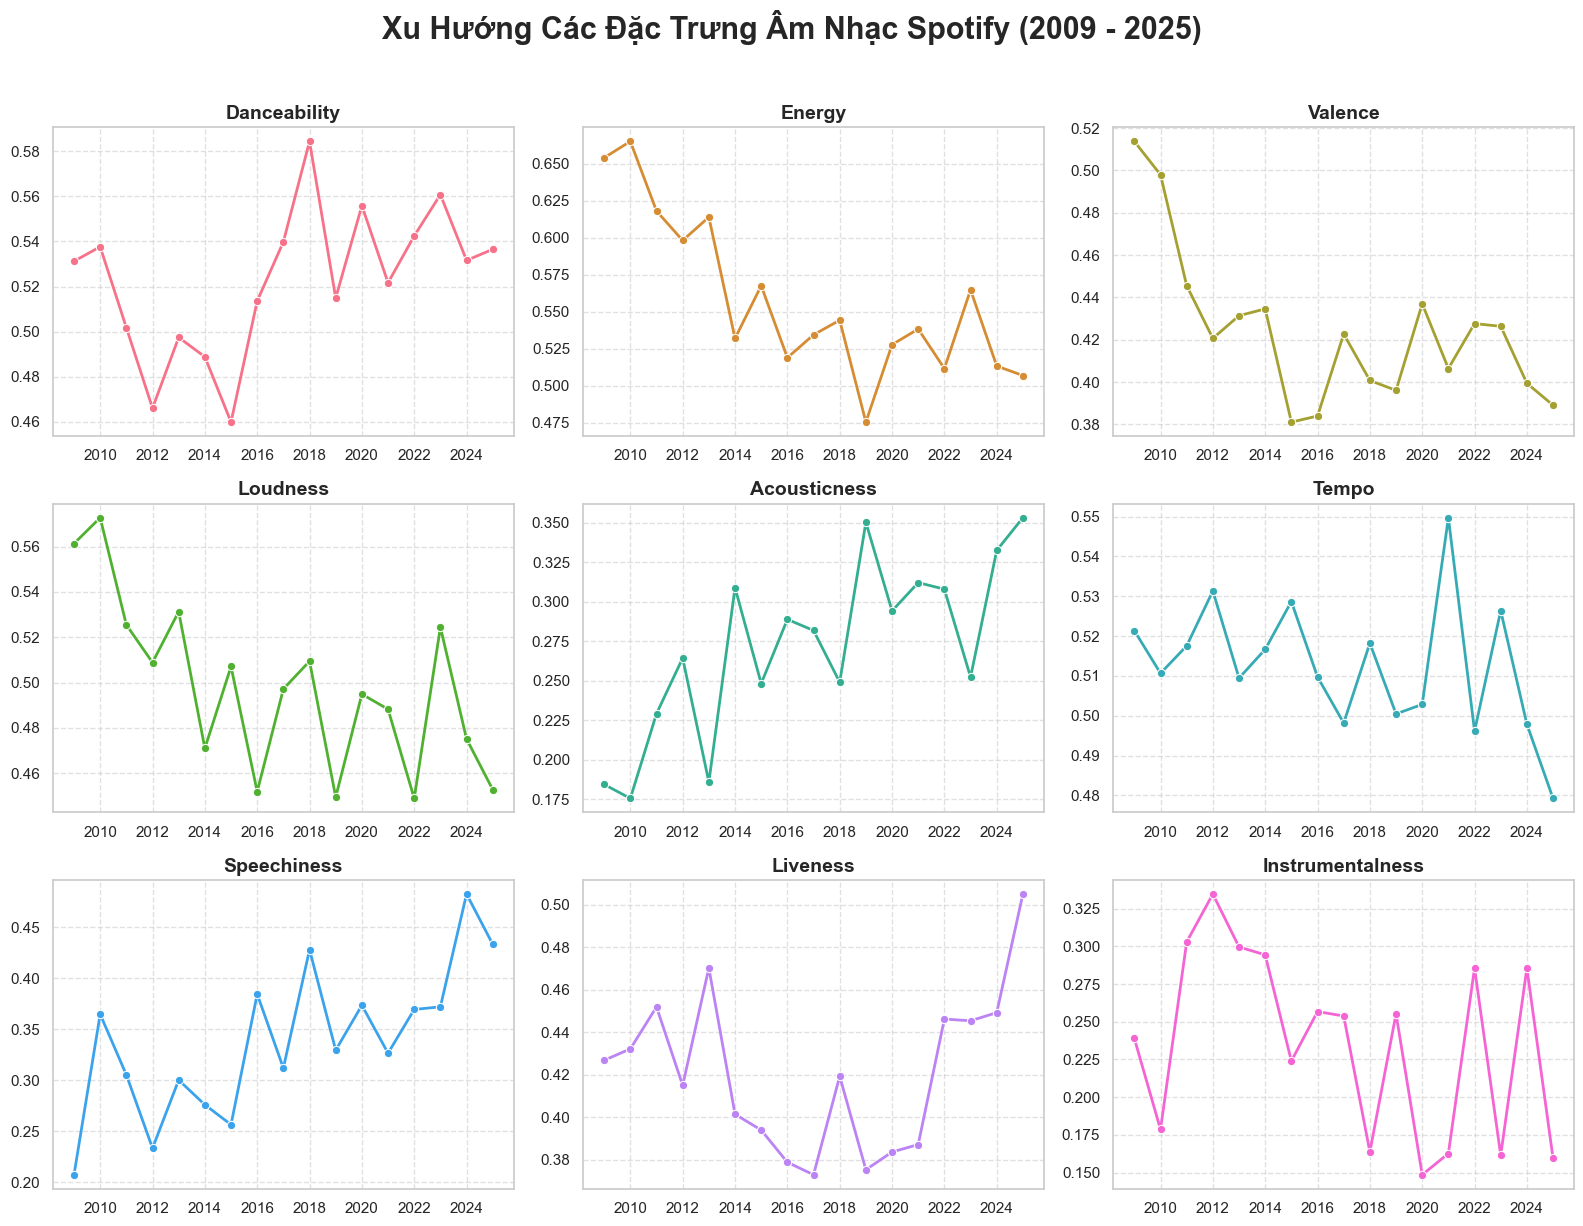

In [10]:
df_eda['release_year'] = pd.to_datetime(df_eda['album_release_date'], errors='coerce').dt.year

yearly_trends = df_eda.dropna(subset=['release_year']).groupby('release_year')[['danceability', 'energy', 'valence', 'loudness', 'acousticness', 'tempo', 'speechiness', 'liveness', 'instrumentalness']].mean().reset_index()

yearly_trends = yearly_trends[(yearly_trends['release_year'] >= 2009) & (yearly_trends['release_year'] <= 2025)]

print("Đang vẽ lưới biểu đồ xu hướng 9 đặc trưng âm học...")

# Danh sách 9 đặc trưng cần vẽ
features = ['danceability', 'energy', 'valence', 'loudness', 'acousticness', 'tempo', 'speechiness', 'liveness', 'instrumentalness']

# Tạo một bảng vẽ lớn gồm 3 hàng x 3 cột
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Xu Hướng Các Đặc Trưng Âm Nhạc Spotify (2009 - 2025)', fontsize=22, fontweight='bold', y=1.02)

axes = axes.flatten()

colors = sns.color_palette("husl", 9)

for i, feature in enumerate(features):
    # Vẽ từng biểu đồ nhỏ vào đúng vị trí axes[i]
    sns.lineplot(x='release_year', y=feature, data=yearly_trends, marker='o', ax=axes[i], color=colors[i], linewidth=2)
    
    # Trang trí từng ô nhỏ
    axes[i].set_title(feature.capitalize(), fontsize=14, fontweight='bold')
    axes[i].set_xlabel('') # Xóa chữ release_year cho đỡ rối mắt
    axes[i].set_ylabel('')
    
    axes[i].set_xticks(np.arange(2010, 2026, 2)) 
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()